# Call-Center Operator Efficiency Analysis

This notebook analyzes the operational efficiency of the "CallMeMaybe" virtual telephony service. The goal is to identify ineffective operators and propose improvements based on data.

In [1]:
# LIBRARY IMPORTS
import pandas as pd
from scipy import stats as st
import math as mt
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime as dt
from datetime import timedelta as td
import seaborn as sns

# Set seaborn theme for better aesthetics
sns.set_theme(style="whitegrid")

## 1. Data Loading, Cleaning, and Preprocessing

We define functions to standardize column names, convert data types, and clean the dataset by removing duplicates and null values.

In [2]:
def clean_column_names(df):
    """
    Standardizes column names to lowercase and replaces spaces with underscores.
    """
    df.columns = df.columns.str.lower().str.replace(' ', '_')
    return df

def preprocess_calls_data(filepath):
    """
    Loads and preprocesses the calls dataset.
    - Cleans column names.
    - Drops duplicates.
    - Converts 'date' to datetime.
    - Drops rows with null 'operator_id' or 'internal'.
    - Calculates 'waiting_time'.
    """
    try:
        df = pd.read_csv(filepath)
        df = clean_column_names(df).drop_duplicates()
        
        # Date conversion
        df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None)
        
        # Handle null values
        initial_len = len(df)
        df = df.dropna(subset=['operator_id', 'internal'])
        loss_data = round((initial_len - len(df)) / initial_len * 100, 2)
        print(f"Dropped {loss_data}% of rows due to null values in 'operator_id' and 'internal'.")
        
        # Type conversion
        df['operator_id'] = df['operator_id'].astype(int)
        df['internal'] = df['internal'].astype(bool)
        
        # Feature Engineering: Waiting Time
        df['waiting_time'] = df['total_call_duration'] - df['call_duration']
        
        return df
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
        return pd.DataFrame()

def preprocess_clients_data(filepath):
    """
    Loads and preprocesses the clients dataset.
    """
    try:
        df = pd.read_csv(filepath)
        df = clean_column_names(df).drop_duplicates()
        df["date_start"] = pd.to_datetime(df["date_start"], format='%Y-%m-%d')
        return df
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
        return pd.DataFrame()

In [3]:
# Execute Data Loading
calls_df = preprocess_calls_data("data/telecom_dataset_new.csv")
clients_df = preprocess_clients_data("data/telecom_clients.csv")

# Display basic info
print("Calls Dataset Info:")
print(calls_df.info())
display(calls_df.sample(5))

print("\nClients Dataset Info:")
print(clients_df.info())
display(clients_df.sample(5))

# Statistical Description
print("\nStatistical description of numeric variables in calls dataset:")
display(calls_df.drop(['user_id', 'operator_id'], axis=1).describe())

Dropped 15.33% of rows due to null values in 'operator_id' and 'internal'.
Calls Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 41491 entries, 1 to 53899
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              41491 non-null  int64         
 1   date                 41491 non-null  datetime64[ns]
 2   direction            41491 non-null  object        
 3   internal             41491 non-null  bool          
 4   operator_id          41491 non-null  int64         
 5   is_missed_call       41491 non-null  bool          
 6   calls_count          41491 non-null  int64         
 7   call_duration        41491 non-null  int64         
 8   total_call_duration  41491 non-null  int64         
 9   waiting_time         41491 non-null  int64         
dtypes: bool(2), datetime64[ns](1), int64(6), object(1)
memory usage: 2.9+ MB
None


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time
16469,166916,2019-10-16,in,False,906400,False,4,575,677,102
23092,167078,2019-10-22,out,False,935348,True,2,0,2,2
4009,166503,2019-09-02,out,False,884412,False,1,36,60,24
41874,167888,2019-11-26,out,False,928886,True,1,0,1,1
4925,166511,2019-10-29,out,False,891414,False,20,1932,2113,181



Clients Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    int64         
 1   tariff_plan  732 non-null    object        
 2   date_start   732 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 17.3+ KB
None


,user_id,tariff_plan,date_start
710,168356,B,2019-10-23
342,167014,C,2019-08-28
376,166555,C,2019-08-08
647,166844,B,2019-08-21
501,168417,B,2019-10-24



Statistical description of numeric variables in calls dataset:


,date,calls_count,call_duration,total_call_duration,waiting_time
count,41491,41491.000000,41491.000000,41491.000000,41491.000000
mean,2019-10-23 15:58:20.739919616,16.921381,1010.940011,1323.153238,312.213227
min,2019-08-02 00:00:00,1.000000,0.000000,0.000000,0.000000
25%,2019-10-06 00:00:00,1.000000,0.000000,67.000000,19.000000
50%,2019-10-28 00:00:00,4.000000,106.000000,289.000000,60.000000
75%,2019-11-14 00:00:00,14.000000,772.000000,1107.000000,219.000000
max,2019-11-28 00:00:00,4817.000000,144395.000000,166155.000000,46474.000000
std,NaN,59.786187,4066.666485,4788.953155,1176.102940


### Data Cleaning Summary
Duplicate rows and rows with missing values in critical columns (`operator_id`, `internal`) have been removed. This ensures the integrity of the statistical analysis. The 'waiting_time' feature has been calculated to measure operator efficiency.

In [4]:
# Filter outliers based on previous analysis (Percentiles 99 and 95)
print("Filtering outliers...")
calls_df = calls_df.query('calls_count <= 166 and total_call_duration <= 5036')
display(calls_df.drop(['user_id', 'operator_id'], axis=1).describe())

Filtering outliers...


,date,calls_count,call_duration,total_call_duration,waiting_time
count,39383,39383.000000,39383.000000,39383.000000,39383.000000
mean,2019-10-23 21:41:38.509509376,10.274687,508.075032,693.094076,185.019044
min,2019-08-02 00:00:00,1.000000,0.000000,0.000000,0.000000
25%,2019-10-07 00:00:00,1.000000,0.000000,62.000000,18.000000
50%,2019-10-29 00:00:00,4.000000,86.000000,252.000000,54.000000
75%,2019-11-15 00:00:00,11.000000,609.000000,891.000000,179.000000
max,2019-11-28 00:00:00,166.000000,4966.000000,5036.000000,5010.000000
std,NaN,16.875669,865.707436,988.585237,373.063812


## 2. Exploratory Data Analysis (EDA)

We visualize the distribution of calls by direction, type (internal/external), and missed status.

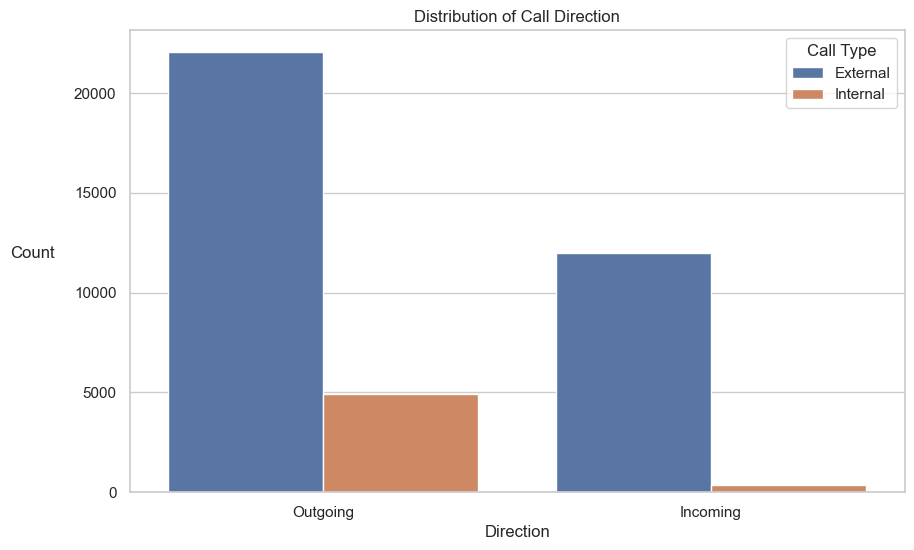

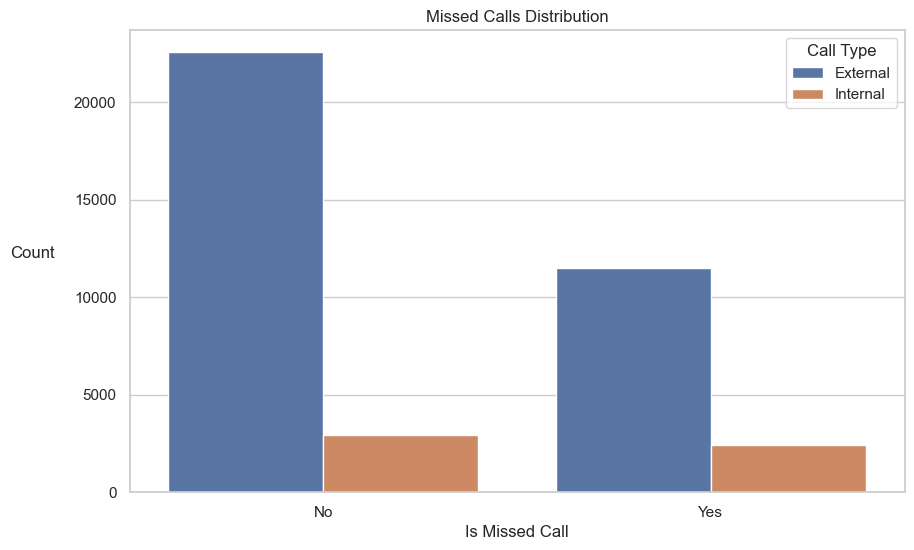

In [5]:
def plot_categorical_distribution(df, x_col, hue_col, title, x_label, y_label="Count", xticks_labels=None):
    """
    Helper function to plot count plots for categorical variables.
    """
    plt.figure(figsize=(10, 6))
    sns.countplot(x=x_col, data=df, hue=hue_col)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label, rotation=0, labelpad=30)
    if xticks_labels:
        plt.xticks(range(len(xticks_labels)), xticks_labels)
    plt.legend(title='Call Type', labels=['External', 'Internal'])
    plt.show()

# Plot Calls Direction
plot_categorical_distribution(
    calls_df, 
    'direction', 
    'internal', 
    'Distribution of Call Direction', 
    'Direction', 
    xticks_labels=['Outgoing', 'Incoming']
)

# Plot Missed Calls
plot_categorical_distribution(
    calls_df, 
    'is_missed_call', 
    'internal', 
    'Missed Calls Distribution', 
    'Is Missed Call',
    xticks_labels=['No', 'Yes']
)

**Observation:** The graphs show that the majority of calls are outgoing (approx. 70%). About 70% of all calls are answered.

### Distribution of `waiting_time` and Definition of Inefficiency Thresholds

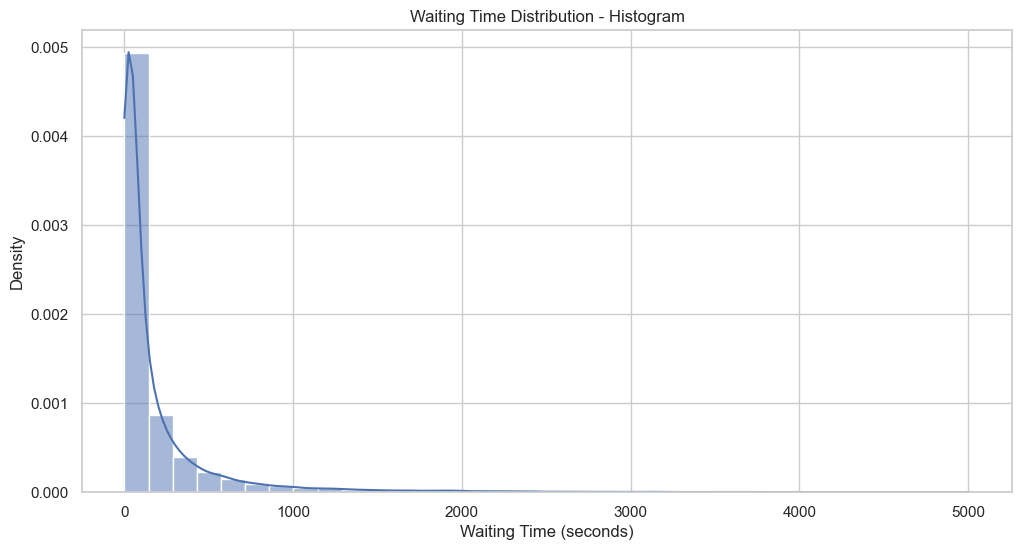

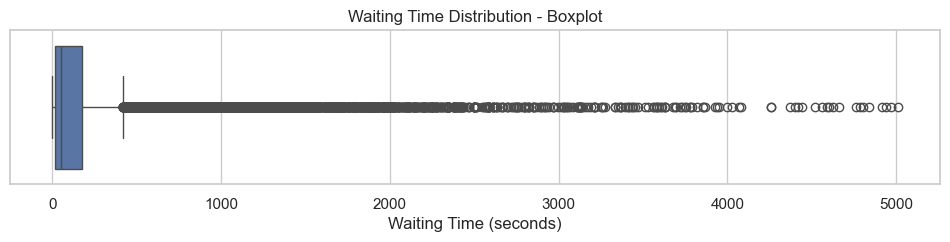

In [6]:
def plot_numeric_distribution(df, x_col, title, x_label, bins=35):
    """
    Helper function to plot histogram and boxplot for numeric variables.
    """
    plt.figure(figsize=(12, 6))
    sns.histplot(x=x_col, data=df, bins=bins, stat='density', kde=True)
    plt.title(f'{title} - Histogram')
    plt.xlabel(x_label)
    plt.ylabel('Density')
    plt.show()
    
    plt.figure(figsize=(12, 2))
    sns.boxplot(data=df, x=x_col)
    plt.title(f'{title} - Boxplot')
    plt.xlabel(x_label)
    plt.show()

# Waiting Time Distribution
plot_numeric_distribution(calls_df, 'waiting_time', 'Waiting Time Distribution', 'Waiting Time (seconds)')

In [7]:
# Aggregating data by Operator to find inefficiency metrics
# We separate incoming and outgoing calls first

def aggregate_operator_stats(df):
    # Incoming calls analysis
    ops_in = df[df['direction'] == 'in'].groupby('operator_id').agg(
        total_incom_calls=('calls_count', 'sum'),
        total_missed_calls=('is_missed_call', 'sum'),
        avg_waiting_time=('waiting_time', 'mean')
    ).reset_index()
    
    ops_in['missed_incom_rate'] = ops_in['total_missed_calls'] / ops_in['total_incom_calls']
    
    # Outgoing calls analysis
    ops_out = df[df['direction'] == 'out'].groupby('operator_id').agg(
        total_outgo_calls=('calls_count', 'sum')
    ).reset_index()
    
    # Merge
    ops_stats = ops_in.merge(ops_out, on='operator_id', how='outer').fillna(0)
    return ops_stats

operator_stats = aggregate_operator_stats(calls_df)

# Helper to print percentiles
def print_percentiles(series, percentiles, name):
    print(f"Percentiles {percentiles} for {name}:")
    print(series.quantile(percentiles))

print_percentiles(operator_stats['missed_incom_rate'], [0.85, 0.90, 0.95, 0.99], "Missed Incoming Call Rate")
print_percentiles(operator_stats['avg_waiting_time'], [0.70, 0.80, 0.90, 0.95, 0.99], "Average Waiting Time")
print_percentiles(operator_stats['total_outgo_calls'], [0.10, 0.20, 0.30], "Total Outgoing Calls")

Percentiles [0.85, 0.9, 0.95, 0.99] for Missed Incoming Call Rate:
0.85    0.010417
0.90    0.020648
0.95    0.053947
0.99    0.204500
Name: missed_incom_rate, dtype: float64
Percentiles [0.7, 0.8, 0.9, 0.95, 0.99] for Average Waiting Time:
0.70     35.323776
0.80     52.103889
0.90     82.694444
0.95    133.271154
0.99    323.892594
Name: avg_waiting_time, dtype: float64
Percentiles [0.1, 0.2, 0.3] for Total Outgoing Calls:
0.1    0.0
0.2    1.0
0.3    4.0
Name: total_outgo_calls, dtype: float64


## 3. Inefficiency Definition
Based on the percentiles analysis, we establish the following efficiency thresholds:

- **Missed Call Rate:** Should be **< 10%**.
- **Average Waiting Time:** Should be **< 80 seconds**.
- **Total Outgoing Calls:** Should be **>= 8**.

**Ineffective Operator Criteria:**
- **Incoming:** Missed rate > 10% OR Avg waiting time > 80s.
- **Outgoing:** Total outgoing calls < 8.

In [8]:
# Flagging Ineffective Operators
operator_stats['ineffective_in'] = (
    (operator_stats['missed_incom_rate'] > 0.10) | 
    (operator_stats['avg_waiting_time'] > 80)
)

operator_stats['ineffective_out'] = operator_stats['total_outgo_calls'] < 8

# Display sample
display(operator_stats.sample(5))

ineffective_ops = operator_stats.query('ineffective_in == True or ineffective_out == True')
effective_ops = operator_stats.query('ineffective_in == False and ineffective_out == False')

print(f"Total Operators: {len(operator_stats)}")
print(f"Ineffective Operators: {len(ineffective_ops)}")
print(f"Effective Operators: {len(effective_ops)}")

,operator_id,total_incom_calls,total_missed_calls,avg_waiting_time,missed_incom_rate,total_outgo_calls,ineffective_in,ineffective_out
149,897894,0.0,0.0,0.000000,0.000000,11.0,False,False
834,944764,214.0,2.0,82.722222,0.009346,256.0,True,False
41,888520,6.0,0.0,18.800000,0.000000,0.0,False,True
200,901586,41.0,0.0,11.629630,0.000000,94.0,False,False
670,936984,70.0,0.0,30.250000,0.000000,0.0,False,True


Total Operators: 1092
Ineffective Operators: 491
Effective Operators: 601


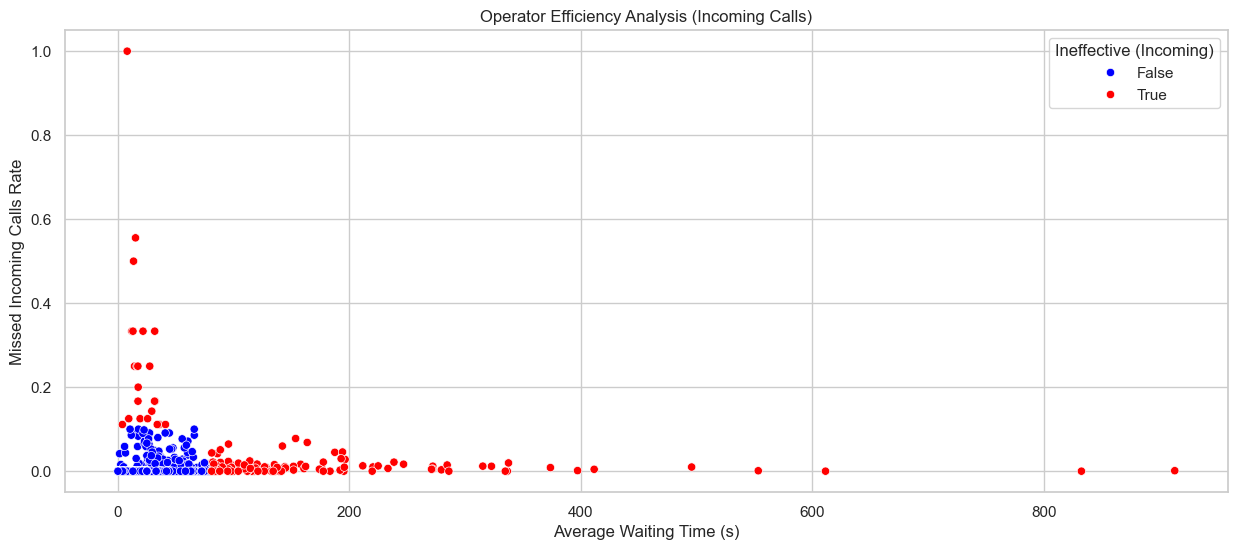

In [17]:
# Visualizing Operator Efficiency
plt.figure(figsize=(15, 6))
sns.scatterplot(
    data=operator_stats, 
    x='avg_waiting_time', 
    y='missed_incom_rate', 
    hue='ineffective_in',
    palette={False: 'blue', True: 'red'}
)
plt.title('Operator Efficiency Analysis (Incoming Calls)')
plt.xlabel('Average Waiting Time (s)')
plt.ylabel('Missed Incoming Calls Rate')
plt.legend(title='Ineffective (Incoming)')
plt.grid(True)
plt.show()

## 4. Hypothesis Testing

We validate our analysis with statistical tests (alpha = 0.05).

1.  **Hypothesis 1:** Avg waiting time for *internal* calls < Avg waiting time for *external* calls.
2.  **Hypothesis 2:** Missed call rate of 'ineffective' operators > 'effective' operators.
3.  **Hypothesis 3:** Missed call rate (Internal) != Missed call rate (External).

In [ ]:
def perform_ttest(group1, group2, test_name):
    """
    Performs Levene's test for variance and T-test for means.
    """
    print(f"--- {test_name} ---")
    
    # Levene Test
    levene_stat, levene_p = st.levene(group1, group2)
    print(f"Levene's Test (Equal Variances): p-value = {levene_p:.4e}")
    equal_var = levene_p > 0.05
    
    # T-Test
    t_stat, t_p = st.ttest_ind(group1, group2, equal_var=equal_var)
    print(f"T-Test: stat = {t_stat:.4f}, p-value = {t_p:.4e}")
    
    if t_p < 0.05:
        print("Result: Reject Null Hypothesis (Significant Difference)\n")
    else:
        print("Result: Fail to Reject Null Hypothesis (No Significant Difference)\n")

# Test 1: Internal vs External Waiting Time
wt_internal = calls_df[calls_df['internal'] == True]['waiting_time']
wt_external = calls_df[calls_df['internal'] == False]['waiting_time']
perform_ttest(wt_internal, wt_external, "Test 1: Internal vs External Waiting Time")

# Test 2: Ineffective vs Effective Missed Rate
mr_ineffective = ineffective_ops['missed_incom_rate']
mr_effective = effective_ops['missed_incom_rate']
perform_ttest(mr_ineffective, mr_effective, "Test 2: Ineffective vs Effective Missed Rate")

--- Test 1: Internal vs External Waiting Time ---
Levene's Test (Equal Variances): p-value = 7.4252e-225
T-Test: stat = -87.3743, p-value = 0.0000e+00
Result: Reject Null Hypothesis (Significant Difference)

--- Test 2: Ineffective vs Effective Missed Rate ---
Levene's Test (Equal Variances): p-value = 3.9343e-05
T-Test: stat = 3.7690, p-value = 1.8224e-04
Result: Reject Null Hypothesis (Significant Difference)



In [20]:
# Test 3: Internal vs External Missed Rate (Z-Test for proportions)
from statsmodels.stats.proportion import proportions_ztest

print("--- Test 3: Internal vs External Missed Rate ---")

internal_calls = calls_df[calls_df['internal'] == True]
external_calls = calls_df[calls_df['internal'] == False]

count = np.array([internal_calls['is_missed_call'].sum(), external_calls['is_missed_call'].sum()])
nobs = np.array([len(internal_calls), len(external_calls)])

z_stat, z_p = proportions_ztest(count, nobs)
print(f"Z-Test: stat = {z_stat:.4f}, p-value = {z_p:.4e}")

if z_p < 0.05:
    print("Result: Reject Null Hypothesis (Significant Difference)\n")
else:
    print("Result: Fail to Reject Null Hypothesis (No Significant Difference)\n")

--- Test 3: Internal vs External Missed Rate ---
Z-Test: stat = 16.3117, p-value = 8.1531e-60
Result: Reject Null Hypothesis (Significant Difference)



## 5. Conclusions

1.  **Waiting Times**: External clients wait significantly longer than internal callers. This is a critical area for improvement.
2.  **Operator Efficiency**: The criteria defined successfully separates operators into distinct groups with statistically significant performance differences.
3.  **Recommendations**: 
    -   Prioritize external calls queue.
    -   Provide training to the identified ineffective operators.
    -   Investigate technical routing issues for outliers with extremely high waiting times.